# Hipotesis 2: Ventaja de local

Paso a paso: evaluamos resultados de local vs visitante.

In [8]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [9]:
matches_path = Path('D:\CIENCIA DE DATOS\PROYECTO_STATSBOMB_V2\data\processed\matches\matches_fact.parquet')
matches = pd.read_parquet(matches_path)
matches.head()

<>:1: SyntaxWarning: invalid escape sequence '\C'
<>:1: SyntaxWarning: invalid escape sequence '\C'
C:\Users\Usuario\AppData\Local\Temp\ipykernel_18976\1125555231.py:1: SyntaxWarning: invalid escape sequence '\C'
  matches_path = Path('D:\CIENCIA DE DATOS\PROYECTO_STATSBOMB_V2\data\processed\matches\matches_fact.parquet')


,match_id,match_date,kick_off,match_datetime,competition_id,season_id,home_team_id,away_team_id,stadium_id,home_score,away_score,match_week,match_status,match_status_360,competition_stage_id,competition_stage_name
0,3895302,2024-04-14,17:30:00,2024-04-14 17:30:00,9,281,904,176,377.0,5,0,29,available,available,1,Regular Season
1,3895292,2024-04-06,15:30:00,2024-04-06 15:30:00,9,281,190,904,560.0,0,1,28,available,available,1,Regular Season
2,3895333,2024-05-05,18:30:00,2024-05-05 18:30:00,9,281,184,904,116458.0,1,5,32,available,available,1,Regular Season
3,3895340,2024-05-12,20:30:00,2024-05-12 20:30:00,9,281,868,904,550.0,0,5,33,available,available,1,Regular Season
4,3895348,2024-05-18,16:30:00,2024-05-18 16:30:00,9,281,904,172,377.0,2,1,34,available,available,1,Regular Season


In [10]:
# Paso 1: etiquetas de resultado
def resultado_local(row):
    if row['home_score'] > row['away_score']:
        return 'local'
    if row['home_score'] < row['away_score']:
        return 'visitante'
    return 'empate'
matches['resultado'] = matches.apply(resultado_local, axis=1)
matches['resultado'].value_counts()

resultado
local        1565
visitante    1102
empate        797
Name: count, dtype: int64

In [11]:
# Paso 2: porcentaje de resultados
resultados_pct = matches['resultado'].value_counts(normalize=True) * 100
resultados_pct

resultado
local        45.178984
visitante    31.812933
empate       23.008083
Name: proportion, dtype: float64

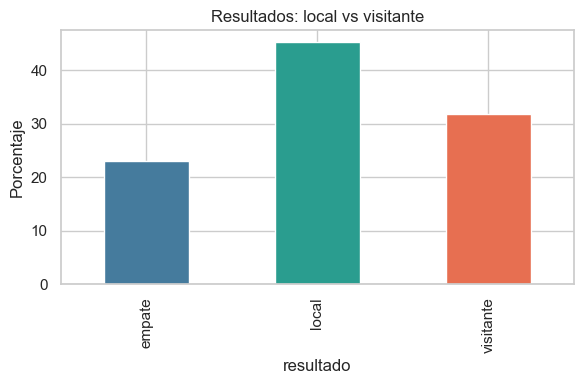

In [12]:
# Paso 2b: grafico de porcentajes de resultado
fig_dir = Path("docs/figures")
fig_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(6, 4))
resultados_pct.sort_index().plot(kind="bar", color=["#457b9d", "#2a9d8f", "#e76f51"])
plt.title("Resultados: local vs visitante")
plt.ylabel("Porcentaje")
plt.tight_layout()
plt.savefig(fig_dir / "h2_resultados_bar.png", dpi=160)
plt.show()

In [13]:
# Paso 3: goles promedio por condicion
goles_local = matches['home_score'].mean()
goles_visita = matches['away_score'].mean()
goles_local, goles_visita

(np.float64(1.596420323325635), np.float64(1.257217090069284))

C:\Users\Usuario\AppData\Local\Temp\ipykernel_18976\4271182008.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=long, x="condicion", y="goles", palette="Set3")


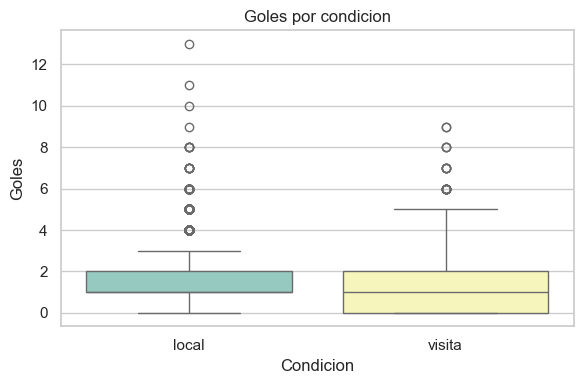

In [14]:
# Paso 3b: distribucion de goles por condicion
long = matches[["home_score", "away_score"]].rename(columns={"home_score": "local", "away_score": "visita"})
long = long.melt(var_name="condicion", value_name="goles")

plt.figure(figsize=(6, 4))
sns.boxplot(data=long, x="condicion", y="goles", palette="Set3")
plt.title("Goles por condicion")
plt.xlabel("Condicion")
plt.ylabel("Goles")
plt.tight_layout()
plt.savefig(fig_dir / "h2_goles_boxplot.png", dpi=160)
plt.show()